In [1]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

## 1. Import Library

Pada tahap awal, dilakukan import terhadap library-library yang akan digunakan selama proses pengolahan citra:

- **`cv2` (OpenCV)** : Library utama untuk pemrosesan citra digital. Digunakan untuk membaca gambar (`imread`), mengkonversi ruang warna (`cvtColor`), dan berbagai operasi citra lainnya.
- **`matplotlib.pyplot`** : Library visualisasi yang digunakan untuk menampilkan gambar dan histogram dalam bentuk plot.
- **`numpy`** : Library komputasi numerik yang digunakan untuk operasi array, termasuk `np.zeros` untuk inisialisasi array dan `np.round` untuk pembulatan nilai.

Ketiga library ini menjadi fondasi utama dalam seluruh proses pengolahan citra pada praktikum ini.

Grayscale    : (450, 800)


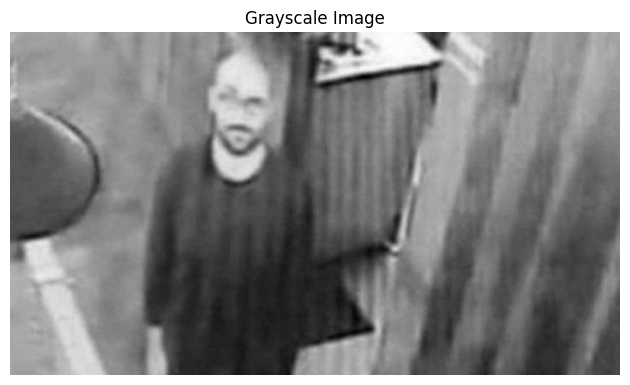

In [ ]:
img_bgr  = cv2.imread('backup.jpg')       
img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

print('Grayscale    :', img_gray.shape)


plt.imshow(img_gray, cmap='gray')
plt.title('Grayscale Image')
plt.axis('off')
plt.tight_layout(); plt.show()

ubah ke grey scale kaya biasa

In [ ]:
def filter(img, size, mode):
    height, width = img.shape
    pad = size // 2
    padded = np.pad(img, pad, mode='edge')
    canvas = np.zeros_like(img, dtype=np.uint8)
    match mode:
        case 'mean':
            area = size * size
            for i in range(height):
                for j in range(width):
                    region = padded[i:i+size, j:j+size]
                    mean = np.sum(region) / area
                    canvas[i, j] = mean

        case 'median':
            for i in range(height):
                for j in range(width):
                    region = padded[i:i+size, j:j+size]
                    median = np.median(region)
                    canvas[i, j] = median

        case 'modus':
            for i in range(height):
                for j in range(width):
                    region = padded[i:i+size, j:j+size]
                    values = region.ravel()
                    count = {}
                    for val in values:
                        if val in count:
                            count[val] += 1
                        else:
                            count[val] = 1
                    max_count = 0
                    mode_val = 0
                    for val, freq in count.items():
                        if freq > max_count:
                            max_count = freq
                            mode_val = val
                    canvas[i, j] = mode_val

    return canvas

def convolution(img, kernel):
    size = kernel.shape[0]
    pad_size = size // 2
    padded = np.pad(img, pad_size, mode='constant')
    canvas = np.zeros_like(img).astype(np.float32)
    height, width = img.shape
    
    for i in range(height):
        for j in range(width):
            region = padded[i:i+size, j:j+size]
            canvas[i, j] = np.sum(region * kernel)
    return canvas

def edge(img, kernelx, kernely):

    gx = convolution(img, kernelx)

    gy = convolution(img, kernely)
    canvas = np.zeros_like(img, dtype=np.float32)
    canvas = np.abs(gx) + np.abs(gy)
    canvas = canvas * 255.0 / np.max(canvas)
    
    # batas nilai dan konversi / clip values and convert
    return np.clip(canvas, 0, 255).astype(np.uint8)




In [ ]:
kernelSmoothing = np.array([
    [1/10, 1/10, 1/10],
    [1/10, 1/5,  1/10],
    [1/10, 1/10, 1/10]
])

kernelSharpening = np.array([
    [1/9, 1/9, 1/9],
    [1/9, 8/9, 1/9],
    [1/9, 1/9, 1/9]
])

sobelX = np.array([
    [-1, 0, 1],
    [-2, 0, 2],
    [-1, 0, 1]
], dtype=np.float32)

sobelY = np.array([
    [1, 2, 1],
    [0, 0, 0],
    [-1, -2, -1]
], dtype=np.float32)

prewittX = np.array([
    [-1, 0, 1],
    [-1, 0, 1],
    [-1, 0, 1]
], dtype=np.float32)

prewittY = np.array([
    [1, 1, 1],
    [0, 0, 0],
    [-1, -1, -1]
], dtype=np.float32)

robertsX = np.array([
    [1, 0],
    [0, -1]
], dtype=np.float32)

robertsY = np.array([
    [ 0, 1],
    [-1, 0]
], dtype=np.float32)

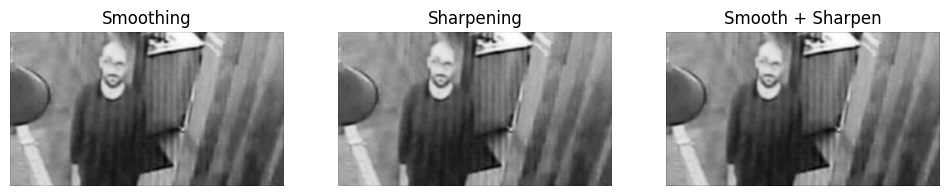

In [59]:

smoothing = convolution(img_gray, kernelSmoothing)
sharpening= convolution(img_gray, kernelSharpening)
smoothsharp= convolution(smoothing, kernelSharpening)
plt.figure(figsize=(12, 10))
plt.subplot(1, 3, 1)
plt.imshow(smoothing, cmap='gray')
plt.title('Smoothing')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(sharpening, cmap='gray')
plt.title('Sharpening')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(smoothsharp, cmap='gray')
plt.title('Smooth + Sharpen')
plt.axis('off')

plt.show()

Dua kernel 3x3 didefinisikan di sini. Kernel smoothing memiliki bobot lebih besar di tengah (1/5) dibanding tepian (1/10), menciptakan efek blur yang sedikit mempertahankan piksel pusat. Kernel sharpening menggunakan nilai tengah 8/9 yang cukup kuat, menghasilkan efek penajaman yang agresif. Yang menarik, notebook ini juga menguji kombinasi keduanya secara berurutan (Smooth lalu Sharp) untuk melihat apakah penghalusan terlebih dahulu bisa menghasilkan ketajaman tepi yang lebih bersih. Tiga hasil ditampilkan berdampingan dalam satu figure.


In [38]:
def to_uint8(img):
    return np.clip(img, 0, 255).astype(np.uint8)

def normalize(img):
    mn, mx = img.min(), img.max()
    if mx == mn:
        return np.zeros_like(img, dtype=np.uint8)
    return to_uint8((img - mn) / (mx - mn) * 255)

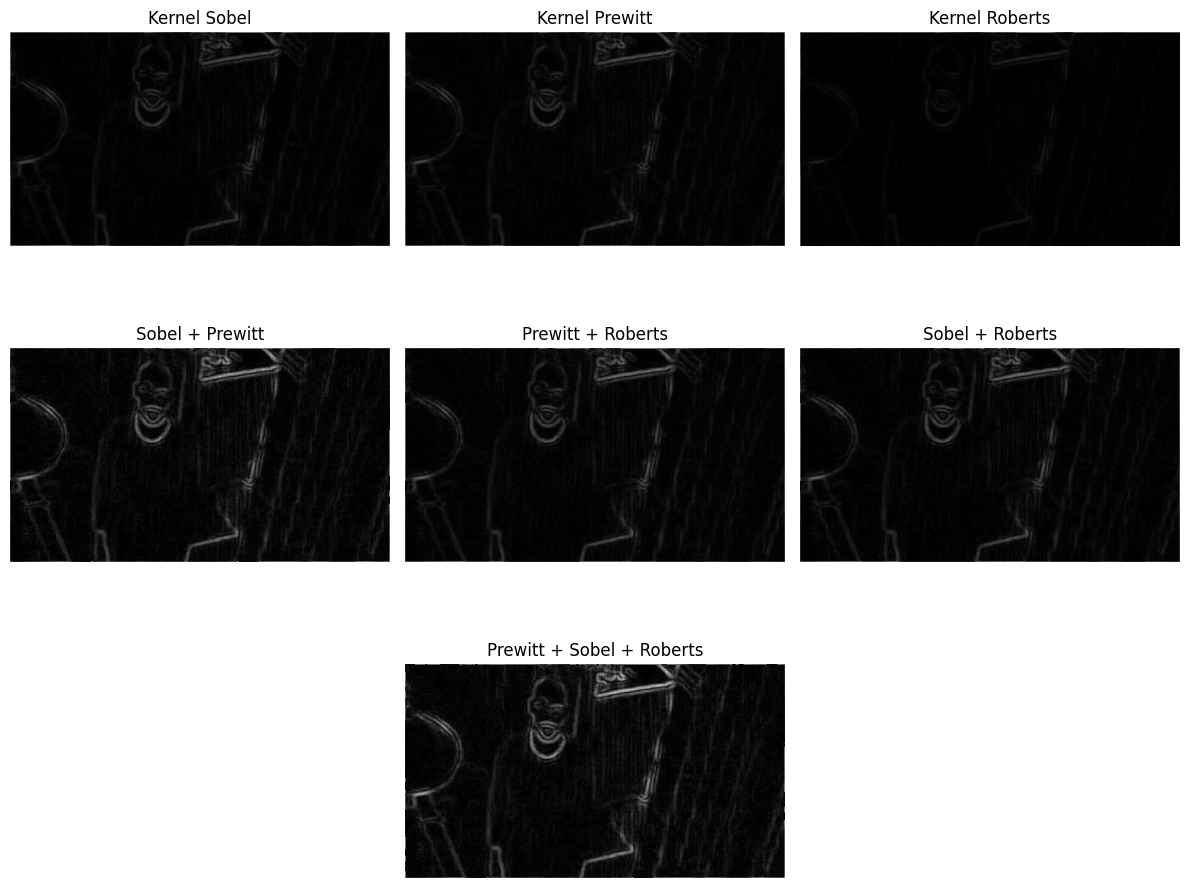

In [ ]:
hasil_tepiSobel   = edge(img_gray, sobelX, sobelY)
hasil_tepiPrewitt = edge(img_gray, prewittX, prewittY)
hasil_tepiRoberts = edge(img_gray, robertsX, robertsY)
sobpre = normalize(hasil_tepiSobel + hasil_tepiPrewitt)
prerob = normalize(hasil_tepiPrewitt + hasil_tepiRoberts)
sobrob = normalize(hasil_tepiSobel + hasil_tepiRoberts)
presobrob = normalize(hasil_tepiPrewitt + hasil_tepiSobel + hasil_tepiRoberts)
plt.figure(figsize=(12, 10))

plt.subplot(3, 3, 1)
plt.imshow(hasil_tepiSobel, cmap='gray')
plt.title("Kernel Sobel")
plt.axis('off')

plt.subplot(3, 3, 2)
plt.imshow(hasil_tepiPrewitt, cmap='gray')
plt.title("Kernel Prewitt")
plt.axis('off')

plt.subplot(3, 3, 3)
plt.imshow(hasil_tepiRoberts, cmap='gray')
plt.title("Kernel Roberts")
plt.axis('off')

plt.subplot(3, 3, 4)
plt.imshow(sobpre, cmap='gray')
plt.title("Sobel + Prewitt")
plt.axis('off')

plt.subplot(3, 3, 5)
plt.imshow(prerob, cmap='gray')
plt.title("Prewitt + Roberts")
plt.axis('off')

plt.subplot(3, 3, 6)
plt.imshow(sobrob, cmap='gray')
plt.title("Sobel + Roberts")
plt.axis('off')

plt.subplot(3, 3, 8) 
plt.imshow(presobrob, cmap='gray')
plt.title("Prewitt + Sobel + Roberts")
plt.axis('off')

plt.tight_layout()
plt.show()

Dua fungsi didefinisikan: edge untuk menghitung deteksi tepi menggunakan dua kernel gradien (horizontal dan vertikal), dan combine_edges untuk menggabungkan beberapa hasil deteksi tepi. Perhitungan tepi menggunakan rumus |Gx| + |Gy| sebagai aproksimasi magnitudo gradien, lalu dinormalisasi ke rentang 0–255. Tiga operator klasik kemudian disiapkan kernelnya: Prewitt yang sederhana dan seragam, Sobel yang memberi bobot lebih pada piksel terdekat, dan Roberts yang menggunakan kernel 2x2 diagonal.

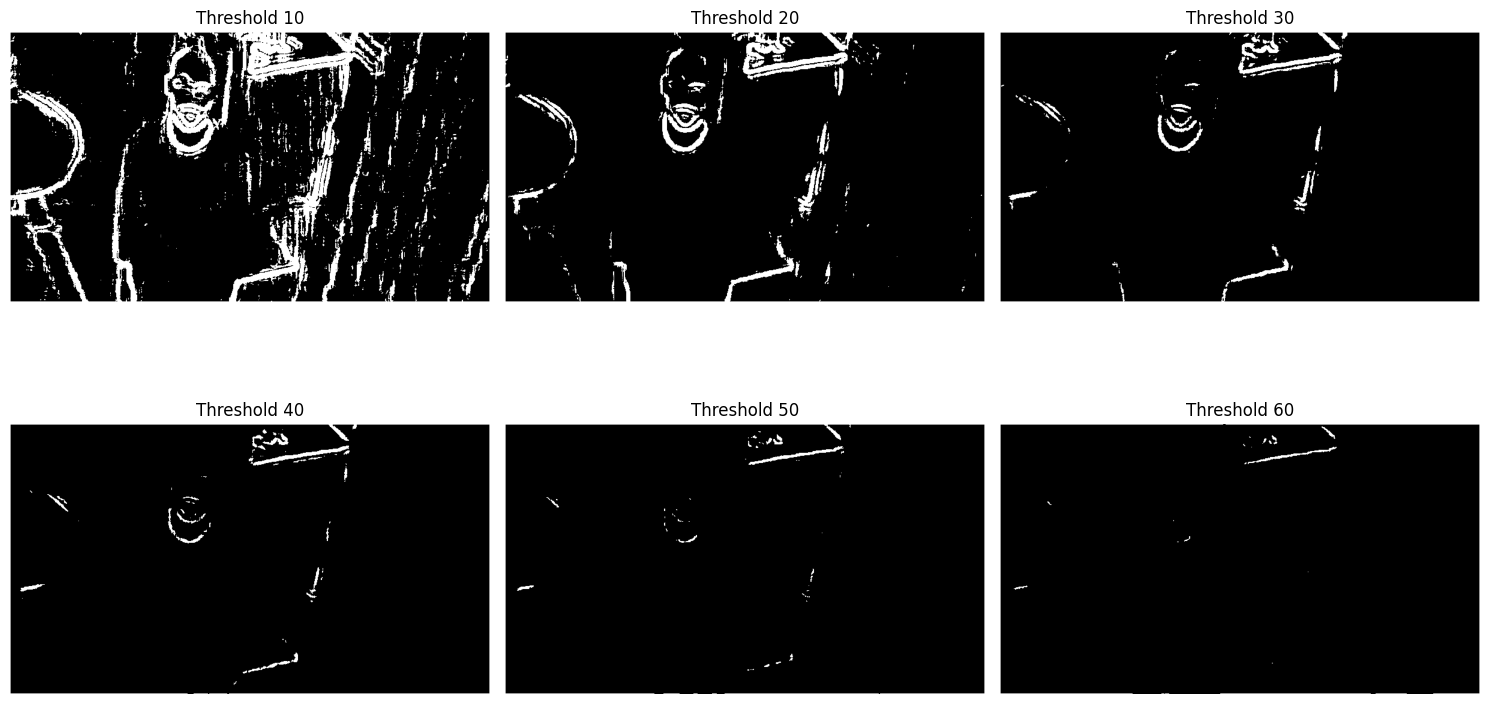

In [56]:
thresholds = [10, 20, 30, 40, 50, 60]
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
for ax, t in zip(axes.flatten(), thresholds):
    binary = np.where(hasil_tepiSobel >= t, 255, 0).astype(np.uint8)
    ax.imshow(binary, cmap='gray')
    ax.set_title(f'Threshold {t}')
    ax.axis('off')

plt.tight_layout()
plt.show()

Analisis Konsep:Hasil deteksi tepi berupa citra dengan rentang nilai gradien yang beragam. Cell ini menerapkan Thresholding (pengambangan batas).Menggunakan np.where(hasil_tepiSobel >= t, 255, 0). Menunjukkan bahwa penentuan nilai threshold ($t$) sangat krusial. Jika nilai $t$ terlalu rendah (misal 10), noise akan ikut terdeteksi sebagai tepi. Jika $t$ terlalu tinggi (misal 60), hanya tepi mayor/utama yang terlihat, sementara detail halus akan hilang (menjadi hitam).


In [62]:
david_bgr  = cv2.imread('david.jpg')
david_rgb  = cv2.cvtColor(david_bgr, cv2.COLOR_BGR2RGB)
david_gray = cv2.cvtColor(david_bgr, cv2.COLOR_BGR2GRAY)

david_edge = edge(david_gray, sobelX, sobelY)

R = david_rgb[:,:,0].astype(np.int32)
G = david_rgb[:,:,1].astype(np.int32)
B = david_rgb[:,:,2].astype(np.int32)
bg_mask = ((G > R + 20) & (G > 80) & (B > R - 30)).astype(np.uint8) * 255
fg_mask = 255 - bg_mask

result = david_rgb.copy()
result[bg_mask == 255] = [255, 255, 255]

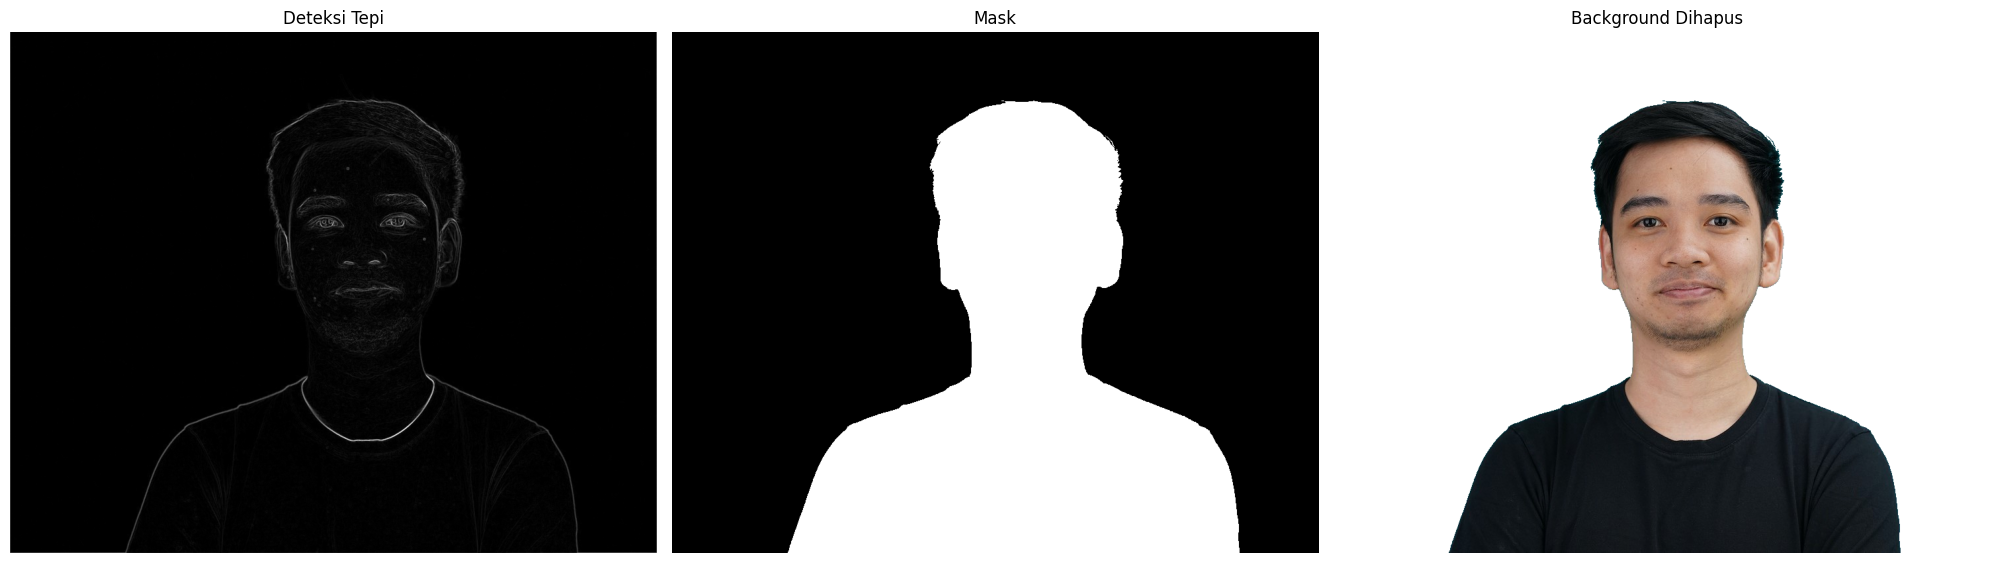

In [ ]:
plt.figure(figsize=(20, 6))

plt.subplot(1, 3, 1)
plt.imshow(david_edge, cmap='gray')
plt.title('Deteksi Tepi')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(fg_mask, cmap='gray')
plt.title('Mask')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(result)
plt.title('Background Dihapus')
plt.axis('off')

plt.tight_layout()
plt.show()

Analisis Konsep:
Ini adalah tahapan implementasi nyata penggabungan konsep segmentasi warna dan deteksi tepi pada citra david.jpg.

Deteksi Tepi: Membuktikan bahwa pada citra dengan pencahayaan baik, garis wajah, rambut, dan baju dapat diekstrak dengan tajam menggunakan metode Sobel.

Pemisahan Kanal RGB & Masking: Sesuai instruksi/hint Modul, background toska dihilangkan bukan dengan deteksi tepi, melainkan dengan membedah kanal Red, Green, dan Blue. Karena toska dominan Hijau dan Biru, logika ((G > R + 20) & (G > 80) & (B > R - 30)) digunakan untuk menemukan secara akurat koordinat background.

Penghapusan Background: Matriks masking (0 dan 255) digunakan sebagai indeks pemotong. Piksel pada citra asli yang masuk area masking background diubah paksa menjadi putih murni [255, 255, 255]. Area subjek (foreground) tetap dipertahankan nilainya.